In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load trained model
model = joblib.load("../models/customer_churn_model.pkl")

# Load feature names
feature_names = joblib.load("../models/feature_names.pkl")

print("Model loaded successfully!")
print("Model type:", type(model))
print("Number of features:", len(feature_names))
print("\nFeature names:")
print(feature_names)

Model loaded successfully!
Model type: <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
Number of features: 39

Feature names:
['Age', 'SeniorCitizen', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 'SupportTickets', 'SatisfactionScore', 'AverageMonthlySpend', 'Gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'InternetService_DSL', 'InternetService_Fiber Optic', 'InternetService_Unknown', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit Card', 'PaymentMethod_Electronic Check', 'PaymentMethod_Mailed Check', 'TenureGroup_1-2 Years', 'TenureGroup_2-4 Years', 'TenureGroup_4-6 Years', 'MonthlyChargeCate

In [4]:
import os

processed_data_path = "../data/processed"

print("Files in processed data folder:\n")

for file in os.listdir(processed_data_path):
    print(file)

Files in processed data folder:

customer_churn_cleaned.csv
customer_churn_feature_engineered.csv
X_train.csv
y_train.csv
y_test.csv
X_test.csv


In [5]:
# Load test data
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

print("Test data loaded successfully!")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nFirst 5 rows of X_test:")
X_test.head()

Test data loaded successfully!
X_test shape: (2000, 39)
y_test shape: (2000, 1)

First 5 rows of X_test:


,Age,SeniorCitizen,TenureMonths,MonthlyCharges,TotalCharges,SupportTickets,SatisfactionScore,AverageMonthlySpend,Gender_Male,Partner_Yes,...,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,PaymentMethod_Mailed Check,TenureGroup_1-2 Years,TenureGroup_2-4 Years,TenureGroup_4-6 Years,MonthlyChargeCategory_Low,MonthlyChargeCategory_Medium,SupportLevel_Low,SupportLevel_Medium
0,-1.639661,-0.695866,-0.758343,-0.359993,-0.716760,-1.147068,0.003336,-0.305522,True,False,...,False,False,False,True,False,False,False,True,True,False
1,-0.540945,-0.695866,1.592689,0.787128,2.051406,-1.147068,0.705591,0.783964,False,True,...,True,False,False,False,False,True,False,False,True,False
2,0.832448,1.437057,-0.946426,-1.112764,-1.041172,-1.147068,-1.401175,-1.125810,True,False,...,False,False,True,True,False,False,True,False,True,False
3,0.942320,1.437057,-0.147075,-0.474077,-0.308733,-1.147068,-0.698920,-0.348979,False,True,...,False,False,True,False,True,False,True,False,True,False
4,-1.419918,-0.695866,1.545669,0.346066,1.581873,-0.267836,-1.401175,0.368183,False,True,...,False,True,False,False,False,True,False,True,True,False


In [6]:
# Create SHAP Tree Explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)

print("SHAP Explainer created successfully!")
print("SHAP values shape:", np.array(shap_values).shape)

SHAP Explainer created successfully!
SHAP values shape: (2000, 39)


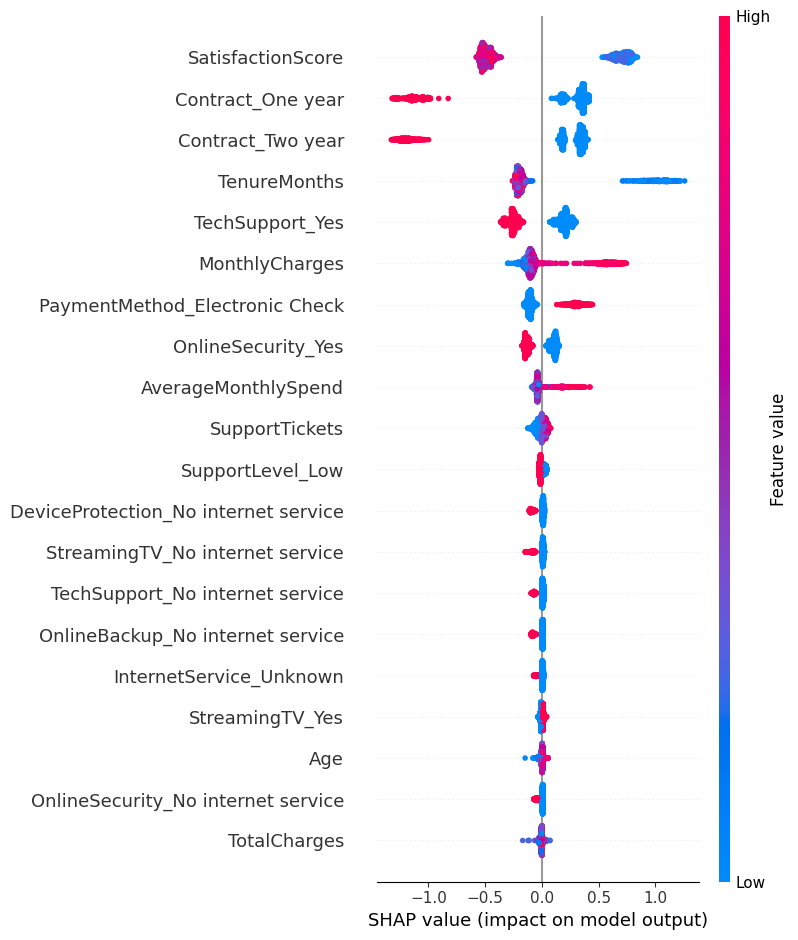

In [7]:
# Generate SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names
)

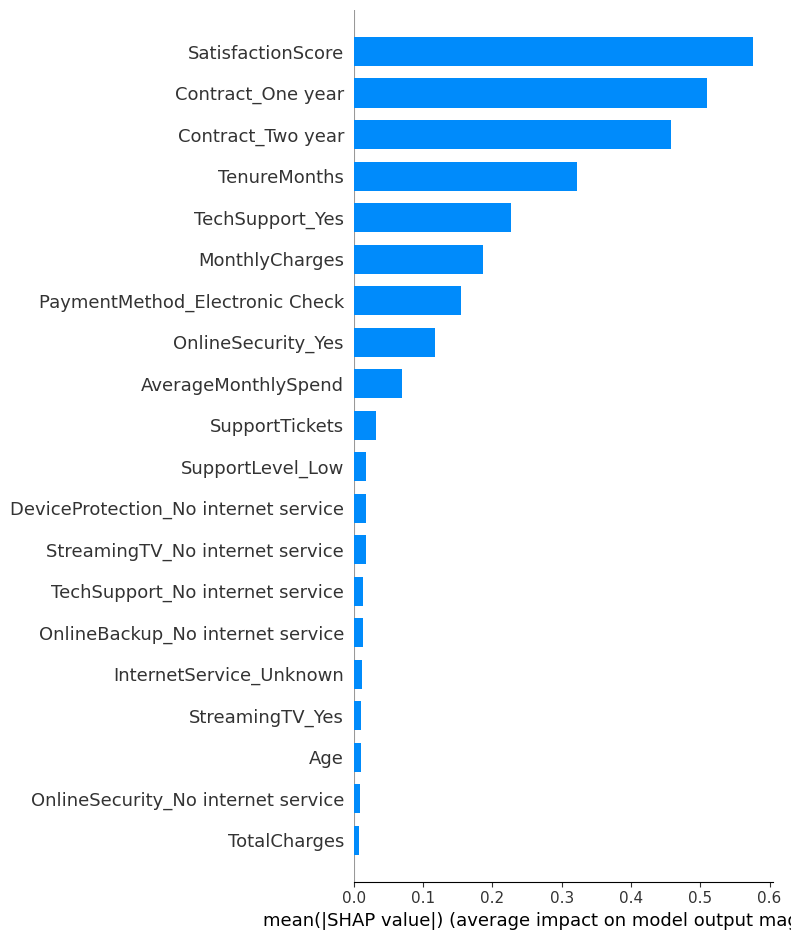

In [8]:
# Generate SHAP Feature Importance Bar Plot
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="bar"
)

In [9]:
# Select one customer
customer_index = 0

customer = X_test.iloc[[customer_index]]

# Make prediction
prediction = model.predict(customer)[0]

# Get churn probability
churn_probability = model.predict_proba(customer)[0][1]

print("Customer Index:", customer_index)
print("Prediction:", "CHURN" if prediction == 1 else "NOT CHURN")
print(f"Churn Probability: {churn_probability * 100:.2f}%")

Customer Index: 0
Prediction: NOT CHURN
Churn Probability: 9.58%


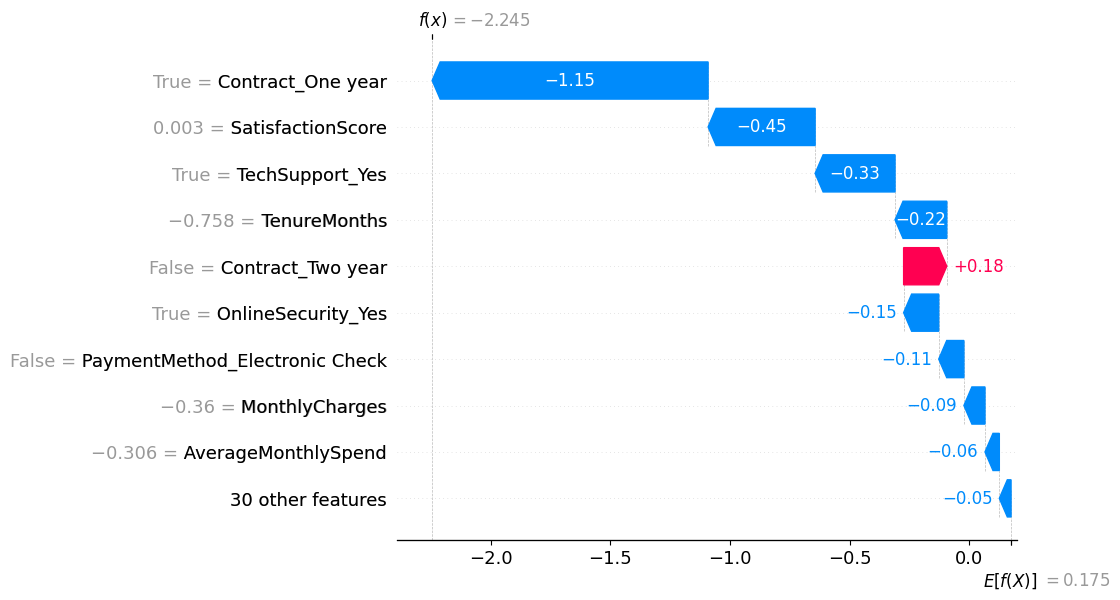

In [10]:
# Calculate SHAP explanation for selected customer
customer_shap_values = explainer(customer)

# Generate SHAP Waterfall Plot
shap.plots.waterfall(customer_shap_values[0])

In [11]:
import os

plots_path = "../reports/figures"

os.makedirs(plots_path, exist_ok=True)

print("Figures folder ready!")

Figures folder ready!


In [12]:
# Save SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.savefig(
    "../reports/figures/shap_summary_plot.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

print("SHAP summary plot saved successfully!")

SHAP summary plot saved successfully!


In [13]:
# Save SHAP Feature Importance Plot

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig(
    "../reports/figures/shap_feature_importance.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

print("SHAP feature importance plot saved successfully!")

SHAP feature importance plot saved successfully!
